# Optimisation (CLEAR / CLARA) — Kickoff Notebook

Starter notebook for the AISSAI Hackathon 2026. This is a double case: pick the facility your team is working on (CLEAR or CLARA) and adjust the data path accordingly.

## 1. Setup

In [ ]:
pip install -r requirements.txt

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import cheetah


## 2. Load lattice
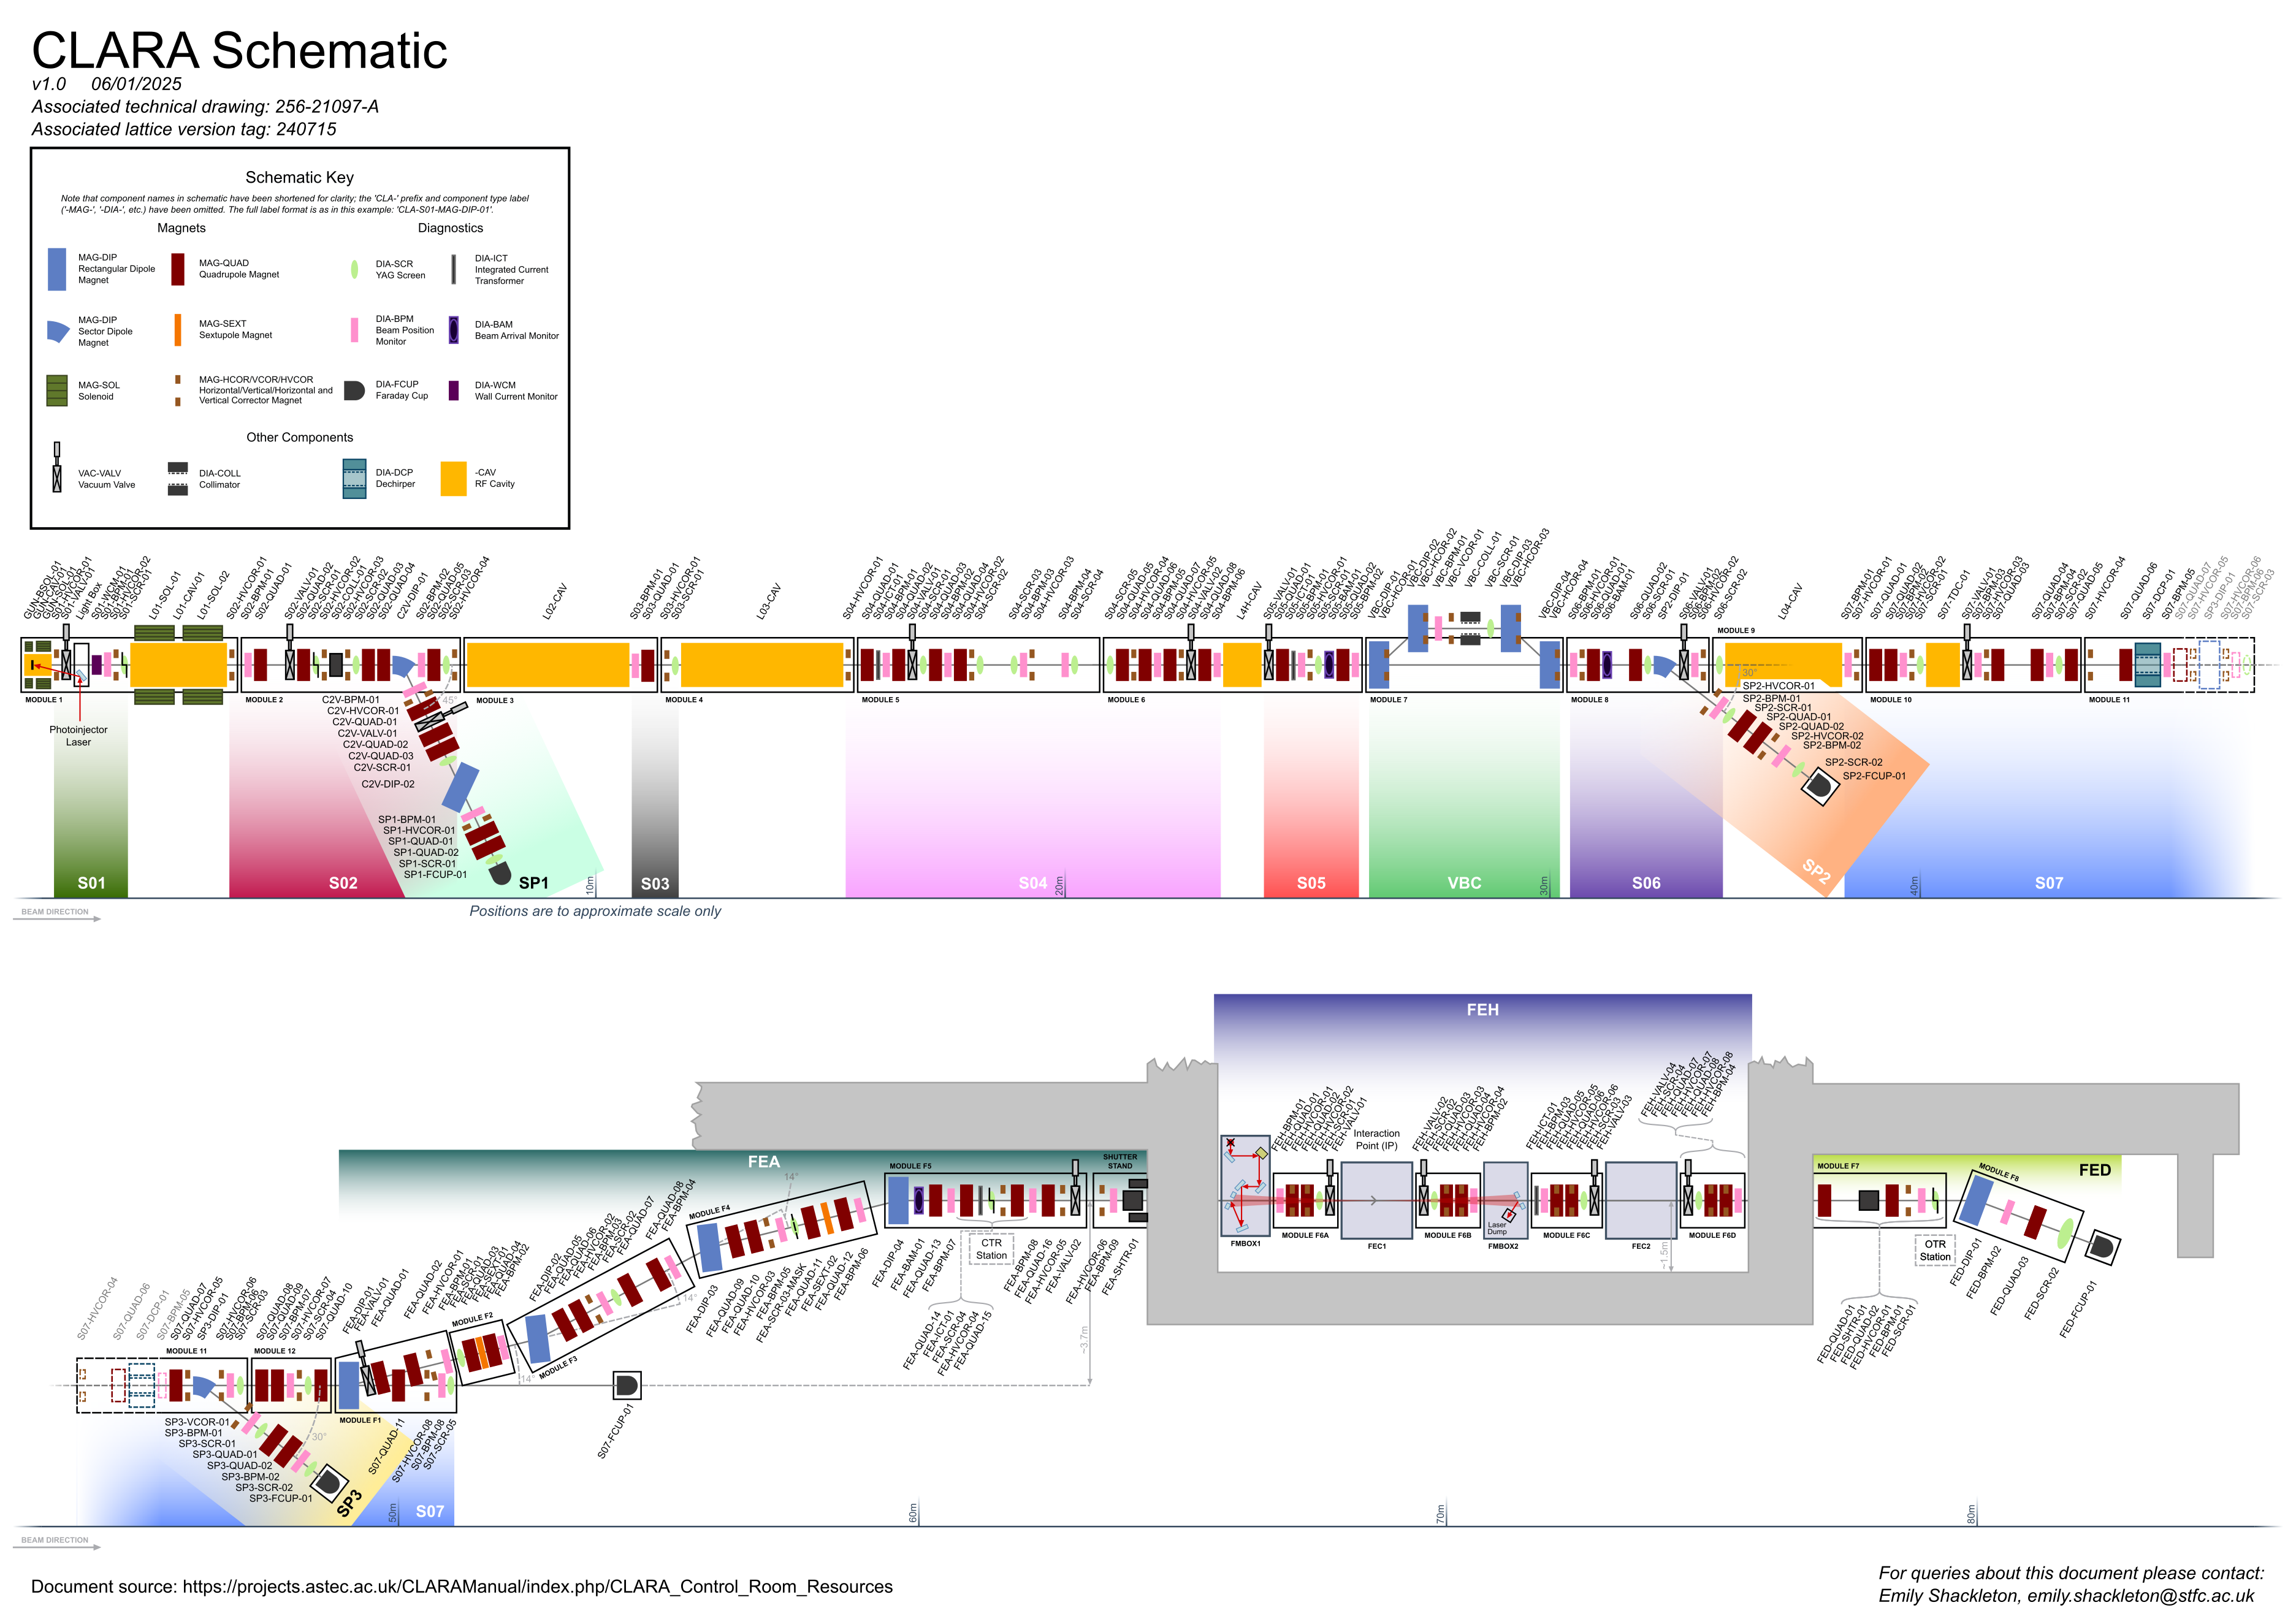

In [58]:
lattice = cheetah.Segment.from_lattice_json("data/clara/lattice_data/CLARA_cheetah.json").partition_at("cla_s01_sim_aper_01", mode="after")[-1]

## 3. Explore

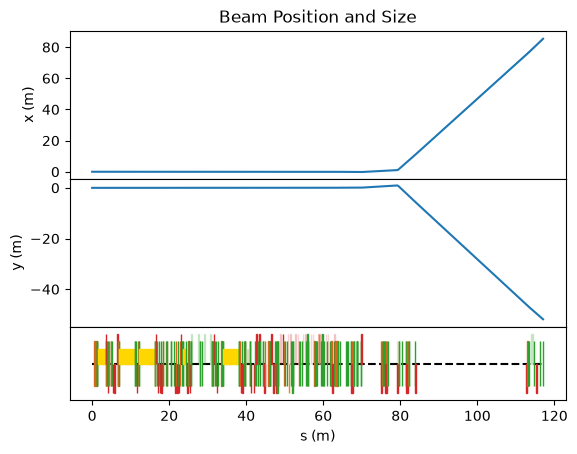

In [62]:
# Example beam
beam = cheetah.ParticleBeam.from_parameters(
            num_particles=int(1e6),
            energy=torch.tensor(4.2e6),
            mu_x=torch.tensor(0.0),
            mu_px=torch.tensor(0.0),
            mu_y=torch.tensor(0.0),
            mu_py=torch.tensor(0.0),
            sigma_x=torch.tensor(1e-5),
            sigma_px=torch.tensor(1e-6),
            sigma_y=torch.tensor(1e-5),
            sigma_py=torch.tensor(1e-6),
            sigma_tau=torch.tensor(1e-6),
            sigma_p=torch.tensor(1e-4),
            dtype=torch.float32,
        )

lattice.track(beam)
_ = lattice.plot_overview(beam)

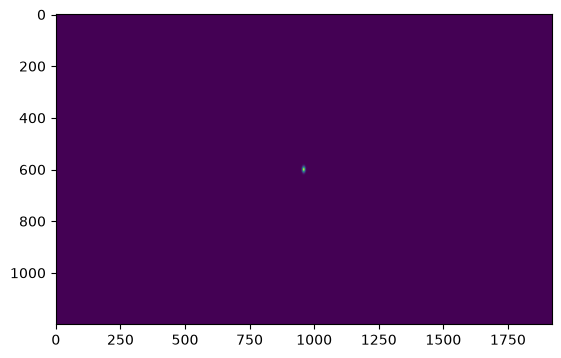

In [60]:
# Plot a screen reading
plt.imshow(lattice.elements[lattice.element_index("CLA-FEH-DIA-SCR-01".lower().replace("-","_"))].reading)

## 4. Baseline model

## 5. Archiver + Image Data
You can find a webUI for searching a sample of CLARA's diagnostic data at [url of webui TODO]
A notebook showing how it can be queried is at [data/clara/machine_data/image_db_example.ipynb]

An example of loading a single configuration from the machine data and setting the cheetah simulation with its values is shown below.


In [61]:
import os
import httpx
from data.clara.lattice_data.utils import update_cheetah_element

BASE_URL = os.environ.get("ARCHIVER_API_URL", "http://apml1.dl.ac.uk:9876")
client = httpx.Client(base_url=BASE_URL, timeout=30.0)

class ApiError(RuntimeError):
    pass

def call(method, path, **kwargs):
    """Issue a request and surface the service's own error message."""
    response = client.request(method, path, **kwargs)
    if response.is_error:
        try:
            detail = response.json().get("detail", response.text)
        except ValueError:
            detail = response.text
        raise ApiError(f"{response.status_code} {method} {path}: {detail}")
    return response.json()


get = lambda path, **kw: call("GET", path, **kw)

print(f"talking to {BASE_URL}")

q1 = get("/api/search", params={"area":"FEH", "from": "2026-04-17T14:49:42Z", "days": 1, "limit": 1})
row = get(f"/api/rows/{q1['rows'][0]['id']}")

for key,val in row['values'].items():
    if ':READI' not in key:
        continue
    if key.split("-")[1] in ["C2V", "SP1", "SP2", "SP3"]: #skip the diagnostic lines, as they are not in the lattice
        continue
    setval = update_cheetah_element(lattice, key, val)
    if setval is not None:
        if not np.allclose(setval[1],setval[2],atol=1e-5):
            print(f"setting {key.split(":")[0]}.{setval[0]} to {setval[1]} from {setval[2]}")

talking to http://apml1.dl.ac.uk:9876
setting CLA-FEA-MAG-QUAD-01.k1 to 10.43220043182373 from 0.0
setting CLA-FEA-MAG-QUAD-02.k1 to -7.4225335121154785 from 0.0022072632225968994
setting CLA-FEA-MAG-QUAD-03.k1 to 10.43220043182373 from 0.0
setting CLA-FEA-MAG-QUAD-04.k1 to -7.4225335121154785 from 0.0
setting CLA-FEA-MAG-QUAD-05.k1 to 10.43220043182373 from 0.0
setting CLA-FEA-MAG-QUAD-06.k1 to -7.4225335121154785 from 0.0
setting CLA-FEA-MAG-QUAD-07.k1 to 10.43220043182373 from 0.0
setting CLA-FEA-MAG-QUAD-08.k1 to -7.4225335121154785 from 0.0
setting CLA-FEA-MAG-QUAD-09.k1 to 10.43220043182373 from 0.0
setting CLA-FEA-MAG-QUAD-10.k1 to -7.4225335121154785 from 0.0
setting CLA-FEA-MAG-QUAD-11.k1 to 10.43220043182373 from 0.0
setting CLA-FEA-MAG-QUAD-12.k1 to -7.4225335121154785 from 0.0
setting CLA-FEA-MAG-QUAD-13.k1 to 17.43461036682129 from 0.0
setting CLA-FEA-MAG-QUAD-14.k1 to -7.683173179626465 from 0.0
setting CLA-FEA-MAG-QUAD-15.k1 to 10.383092880249023 from -0.0044174805187895

## 5. Your work starts here

See `objectives.md` for the easy / medium / hard objectives.